# importing libraries


In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


# Loading dataset

In [2]:
data = pd.read_csv("C:\\Users\\acer\\Downloads\\mymoviedb.csv" , encoding="utf-8" ,lineterminator ="\n")

In [3]:
data

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
...,...,...,...,...,...,...,...,...,...
9822,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9823,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9824,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9825,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [5]:
data.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


# •	We have data frame of 9827 rows and 9 columns.

# •	We have to covert Release_date  into years and into  integer type .

# •	Removing or Dropping the unnecessary colums that we would not use in analysis like overview  , Original_Language , Poster_Url.

# •	Categorized the Vote_average for better analysis.

# * Removing the White space , comma from the gener column for better analysis.


# converting the release_date into years 

In [6]:
data['Release_Date']= pd.to_datetime(data['Release_Date'])
print(data['Release_Date'].dtypes)

datetime64[ns]


In [7]:
data['Release_Date']=data['Release_Date'].dt.year

# Dropping the Unwanted Columns like Overview , Original_Language and Poster_Url

In [9]:


data.drop(['Overview','Original_Language','Poster_Url'] , axis=1 , inplace =True)

# categorized the vote_average column into Categorized_column..
#  we devide the Vote_average values into 4 categorise: Popular, average , below_average ,not_popular

In [10]:


def categorized_col(data, col, labels):
    edges=[data[col].describe()['min'],
           data[col].describe()['25%'],
           data[col].describe()['50%'],
           data[col].describe()['75%'],
           data[col].describe()['max']]
    
    data[col] = pd.cut(data[col],edges ,labels = labels , duplicates ='drop')
    return data

In [11]:
labels =['Not_popular' ,'Below_Average' ,'Average' ,'Popular']
categorized_col(data, "Vote_Average" ,labels)
data['Vote_Average'].unique()

['Popular', 'Below_Average', 'Average', 'Not_popular', NaN]
Categories (4, object): ['Not_popular' < 'Below_Average' < 'Average' < 'Popular']

In [12]:
data.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,Below_Average,Thriller
3,2021,Encanto,2402.201,5076,Popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,Average,"Action, Adventure, Thriller, War"


In [13]:
data['Vote_Average'].value_counts()

Vote_Average
Not_popular      2467
Popular          2450
Average          2412
Below_Average    2398
Name: count, dtype: int64

In [14]:
data.dropna(inplace=True)
data.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [15]:
# removing the whitespace , comma from the gener and split gener of each movie
data['Genre'] = data['Genre'].str.split(', ')
data = data.explode('Genre').reset_index(drop=True)


In [16]:
data.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


# casting column into Categories

In [17]:


data['Genre'] = data['Genre'].astype('category')
data['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


In [22]:
data['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

Data Visualization....


# What is the mostt frequentg genre of movies released on Netflix?

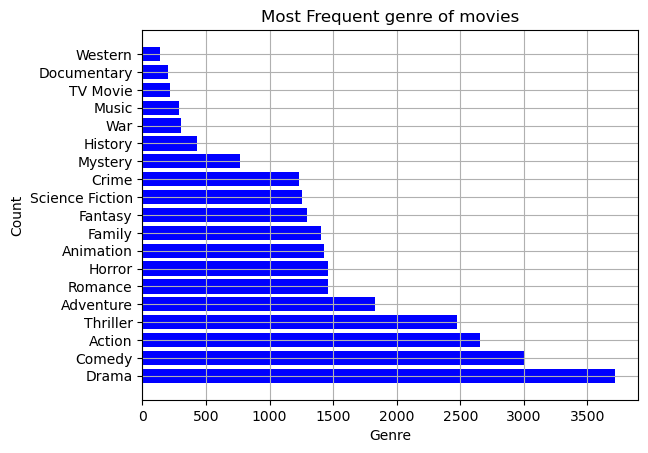

In [39]:
count = data['Genre'].value_counts().sort_values(ascending =False)
plt.barh(count.index , count.values , color ="blue")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.grid()
plt.title("Most Frequent genre of movies")
plt.show()

# Which has highest votes in vote_avg column

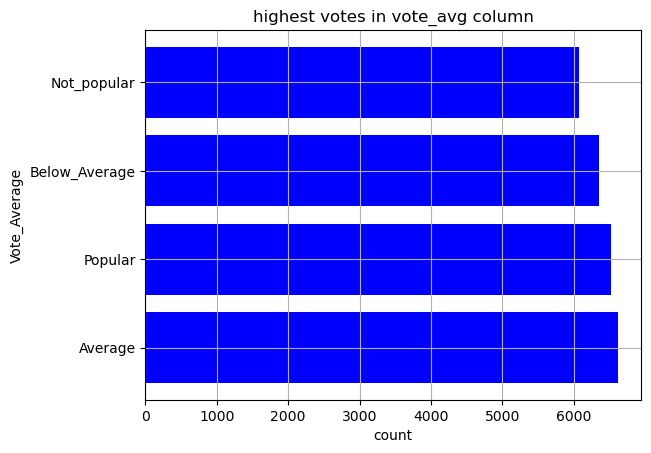

In [44]:
count = data['Vote_Average'].value_counts()
plt.barh(count.index , count.values , color ="blue")
plt.ylabel('Vote_Average')
plt.xlabel("count")
plt.grid()
plt.title("highest votes in vote_avg column")
plt.show()

# What movie got the highest popularity ? what's genre?


In [45]:
data[data['Popularity'] == data['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction


# What movie got the lowest popularity ? what's genre?

In [46]:
data[data['Popularity']==data['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,Average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,Average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,Average,History
25549,1984,Threads,13.354,186,Popular,War
25550,1984,Threads,13.354,186,Popular,Drama
25551,1984,Threads,13.354,186,Popular,Science Fiction


# Which year has the most filmmed movies?


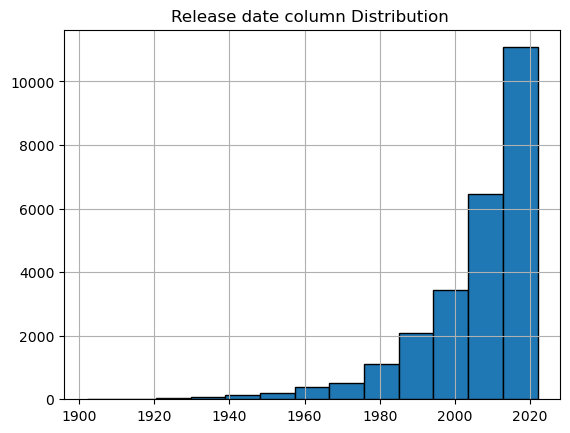

In [53]:
data['Release_Date'].hist(bins=13,edgecolor = "black")
plt.title("Release date column Distribution " )
plt.show()

# 📌 Conclusion

# Q1: What is the most frequent genre in the dataset?
Drama is the most frequent genre in our dataset and appears in more than 14% of the movies among 19 other genres.

# Q2: Which genre has the highest votes?
About 25.5% of the dataset has popular votes (6520 rows). Drama again receives the highest popularity among fans, appearing in more than 18.5% of movies.

# Q3: Which movie has the highest popularity? What is its genre?
Spider-Man: No Way Home has the highest popularity rate in the dataset. Its genres are Action, Adventure, and Science Fiction.

# Q4: Which movie has the lowest popularity? What is its genre?
The United States, Thread has the lowest popularity rate in the dataset. Its genres include Music, Drama, War, and Science Fiction.

# Q5: Which year has the most filmed movies?
The year 2020 has the highest number of filmed movies in the dataset.